# Setup

In [1]:
from IPython.display import HTML, Markdown, display

In [2]:
# For google colab only
# from google.colab import userdata
# api_key = userdata.get('GOOGLE_API_KEY')

# For Local system
import os
from dotenv import load_dotenv

load_dotenv()  # This loads the variables from .env
api_key = os.getenv("GOOGLE_API_KEY")

In [3]:
import os
from google import genai
from google.genai import types
from google.adk.agents import LlmAgent
from google.adk.models.google_llm import Gemini
from google.adk.runners import InMemoryRunner, Runner
from google.adk.sessions import InMemorySessionService
from google.adk.tools import google_search, AgentTool, ToolContext
from google.adk.code_executors import BuiltInCodeExecutor

In [4]:
def show_python_code_and_result(response):
  # Helper function that prints the generated Python code and results from the code execution tool
  for i in range(len(response)):
    # Check if the response contains a valid function call result from the code executor
    if (
        (response[i].content.parts)
        and (response[i].content.parts[0])
        and (response[i].content.parts[0].function_response)
        and (response[i].content.parts[0].function_response.response)
    ):
      response_code = response[i].content.parts[0].function_response.response
      if "result" in response_code and response_code["result"] != "```":
        if "tool_code" in response_code["result"]:
          print(
              "Generated Python Code >> ",
              response_code["result"].replace("tool_code", ""),
          )
        else:
          print("Generated Python Response >> ", response_code["result"])

In [5]:
retry_config = types.HttpRetryOptions(
    attempts=5,  # Maximum retry attempts
    exp_base=7,  # Delay multiplier
    initial_delay=1,
    http_status_codes=[429, 500, 503, 504],  # Retry on these HTTP errors
)

In [7]:
# Set API key as environment variable
# os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')

client = genai.Client(api_key=api_key)

for model in client.models.list():
  print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [8]:
# Define helper functions that will be reused throughout the notebook
async def run_session(
    runner_instance: Runner,
    user_queries: list[str] | str = None,
    session_name: str = "default",
):
    print(f"\n ### Session: {session_name}")

    # Get app name from the Runner
    app_name = runner_instance.app_name

    # Attempt to create a new session or retrieve an existing one
    try:
        session = await session_service.create_session(
            app_name=app_name, user_id=USER_ID, session_id=session_name
        )
    except:
        session = await session_service.get_session(
            app_name=app_name, user_id=USER_ID, session_id=session_name
        )

    # Process queries if provided
    if user_queries:
        # Convert single query to list for uniform processing
        if type(user_queries) == str:
            user_queries = [user_queries]

        # Process each query in the list sequentially
        for query in user_queries:
            print(f"\nUser > {query}")

            # Convert the query string to the ADK Content format
            query = types.Content(role="user", parts=[types.Part(text=query)])

            # Stream the agent's response asynchronously
            async for event in runner_instance.run_async(
                user_id=USER_ID, session_id=session.id, new_message=query
            ):
                # Check if the event contains valid content
                if event.content and event.content.parts:
                    # Filter out empty or "None" responses before printing
                    if (
                        event.content.parts[0].text != "None"
                        and event.content.parts[0].text
                    ):
                        print(f"{MODEL_NAME} > ", event.content.parts[0].text)
    else:
        print("No queries!")


print("Helper functions defined.")

Helper functions defined.


# 1. Agent Observability: Logs, Traces and Metrics

**What is Agent Observability?**

- The challenge: Unlike traditional software that fails predictably, AI agents can fail mysteriously. Example:
```
User: "Find quantum computing papers"
Agent: "I cannot help with that request."
You: 😭 WHY?? Is it the prompt? Missing tools? API error?
```
- The Solution: Agent observability gives you complete visibility into your agent's decision-making process. You'll see exactly what prompts are sent to the LLM, which tools are available, how the model responds, and where failures occur.
```
DEBUG Log: LLM Request shows "Functions: []" (no tools!)
You: 🎯 Aha! Missing google_search tool - easy fix!
```

**Foundational pillars of Agent Observability**

1. `Logs`: A log is a record of a single event, telling you what happened at a specific moment.
2. `Traces`: A trace connects the logs into a single story, showing you why a final result occurred by revealing the entire sequence of steps.
3. `Metrics`: Metrics are the summary numbers (like averages and error rates) that tell you how well the agent is performing overall.

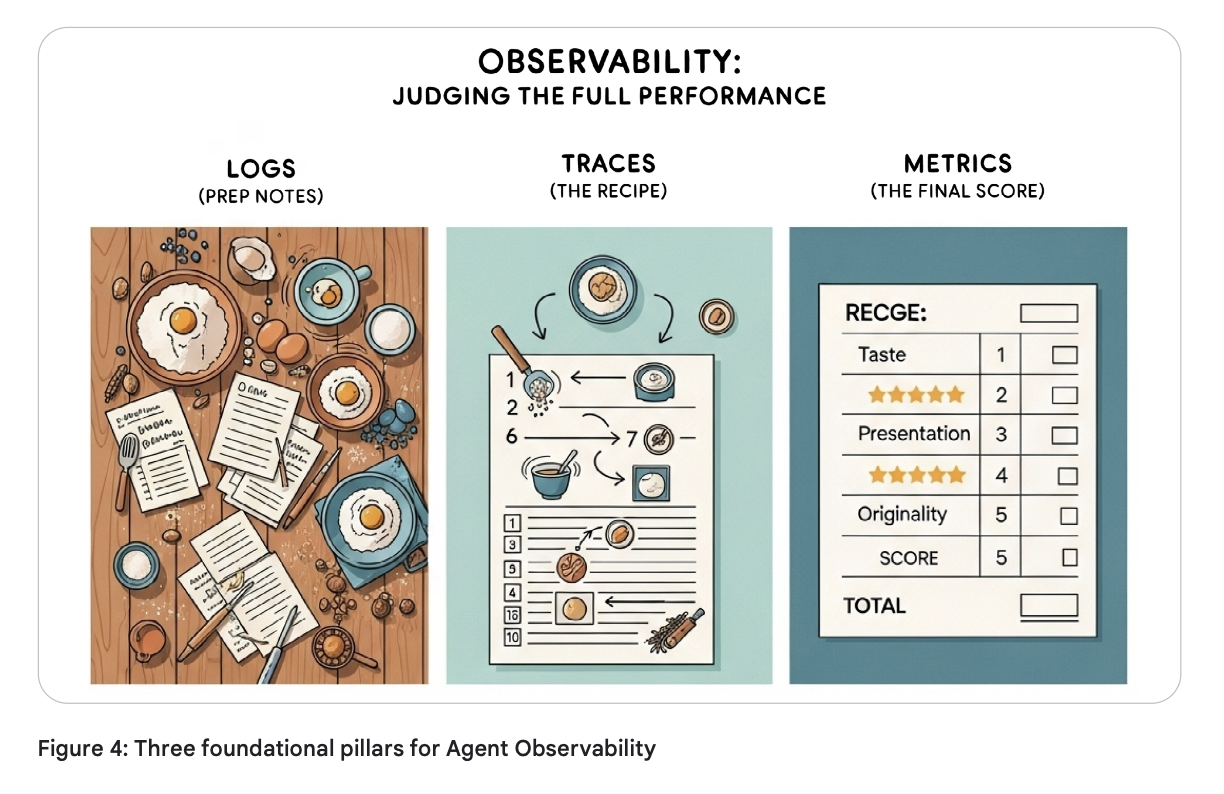

Let's configure logging for our debugging session. The following cell makes sure we also capture other log levels, like DEBUG.

In [ ]:
import logging
import os

# Clean up any previous logs
for log_file in ["logger.log", "web.log", "tunnel.log"]:
    if os.path.exists(log_file):
        os.remove(log_file)
        print(f"Cleaned up {log_file}")

# Configure logging with DEBUG log level.
logging.basicConfig(
    filename="logger.log",
    level=logging.DEBUG,
    format="%(filename)s:%(lineno)s %(levelname)s:%(message)s",
)

print("Logging configured")

Logging configured


In [ ]:
from google.colab.output import eval_js

def get_adk_proxy_url():
    ADK_PORT = 8000
    url = eval_js(f"google.colab.kernel.proxyPort({ADK_PORT})")
    print(f"ADK Web UI will be available at: {url}")
    return url

## 1.1) Debugging with ADK WebUI

**Create a "Research Paper Finder" Agent**

**Goal**: Build a research paper finder agent that helps users find academic papers on any topic.

But first, let's intentionally create an incorrect version of the agent to practice debugging! We'll start by creating a new agent folder using the `adk create` CLI command.

In [ ]:
!adk create research_agent --model gemini-2.5-flash-lite --api_key $api_key

/usr/local/lib/python3.12/dist-packages/google/adk/features/_feature_decorator.py:72: UserWarning: [EXPERIMENTAL] feature FeatureName.PLUGGABLE_AUTH is enabled.
  check_feature_enabled()

Agent created in /content/research_agent:
- .env
- __init__.py
- agent.py

⚠️  WARNING: Secrets (like GOOGLE_API_KEY) are stored in .env.
Please ensure .env is added to your .gitignore to avoid committing secrets to version control.



In [ ]:
!cd research_agent/

In [ ]:
!pwd

/content


**Agent Definition**

- We'll configure it as an `LlmAgent`, give it a name, model and instruction.
- The `root_agent` gets the user prompt and delegates the search to the `google_search_agent`.
- Then, the agent uses the `count_papers` tool to count the number of papers returned.

In [ ]:
%%writefile /content/research_agent/agent.py

from google.adk.agents import LlmAgent
from google.adk.models.google_llm import Gemini
from google.adk.tools.agent_tool import AgentTool
from google.adk.tools.google_search_tool import google_search

from google.genai import types
from typing import List

retry_config = types.HttpRetryOptions(
    attempts=5,  # Maximum retry attempts
    exp_base=7,  # Delay multiplier
    initial_delay=1,
    http_status_codes=[429, 500, 503, 504],  # Retry on these HTTP errors
)

# ---- Intentionally pass incorrect datatype - `str` instead of `List[str]` ----
def count_papers(papers: str):
    """
    This function counts the number of papers in a list of strings.
    Args:
      papers: A list of strings, where each string is a research paper.
    Returns:
      The number of papers in the list.
    """
    return len(papers)


# Google Search agent
google_search_agent = LlmAgent(
    name="google_search_agent",
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    description="Searches for information using Google search",
    instruction="""Use the google_search tool to find information on the given topic. Return the raw search results.
    If the user asks for a list of papers, then give them the list of research papers you found and not the summary.""",
    tools=[google_search]
)


# Root agent
root_agent = LlmAgent(
    name="research_paper_finder_agent",
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    instruction="""Your task is to find research papers and count them.

    You MUST ALWAYS follow these steps:
    1) Find research papers on the user provided topic using the 'google_search_agent'.
    2) Then, pass the papers to 'count_papers' tool to count the number of papers returned.
    3) Return both the list of research papers and the total number of papers.
    """,
    tools=[AgentTool(agent=google_search_agent), count_papers]
)

Overwriting /content/research_agent/agent.py


**Running the Agent**

Run the agent with the `adk web --log_level DEBUG` CLI command.

The key here is `--log_level DEBUG` - this shows us:

- Full LLM Prompts: The complete request sent to the language model, including system instructions, history, and tools.
- Detailed API responses from services.
- Internal state transitions and variable values.

Other log levels include: INFO, ERROR and WARNING.

In [ ]:
url_prefix = get_adk_proxy_url()

ADK Web UI will be available at: https://8000-m-s-kkb-use4a1-2mezzznfsr8x1-a.us-east4-1.prod.colab.dev


you can start the ADK web UI with the --log_level parameter.

👉 Note: The following cell will not "complete", but will remain running and serving the ADK web UI until you manually stop the cell.

In [ ]:
!adk web --log_level DEBUG --url_prefix {url_prefix}

/usr/local/lib/python3.12/dist-packages/google/adk/features/_feature_decorator.py:72: UserWarning: [EXPERIMENTAL] feature FeatureName.PLUGGABLE_AUTH is enabled.
  check_feature_enabled()
2026-04-15 21:37:18,974 - DEBUG - service_registry.py:206 - services.py not found in /content, skipping.
2026-04-15 21:37:18,974 - INFO - service_factory.py:266 - Using in-memory memory service
2026-04-15 21:37:18,974 - INFO - local_storage.py:84 - Using per-agent session storage rooted at /content
2026-04-15 21:37:18,975 - INFO - local_storage.py:110 - Using file artifact service at /content/.adk/artifacts
/usr/local/lib/python3.12/dist-packages/google/adk/cli/fast_api.py:198: UserWarning: [EXPERIMENTAL] InMemoryCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  credential_service = InMemoryCredentialService()
/usr/local/lib/python3.12/dist-packages/google/adk/auth/credential_service/in_memory

INFO:     Shutting down
INFO:     Finished server process [7408]
ERROR:    Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/runners.py", line 195, in run
    return runner.run(main)
           ^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "uvloop/loop.pyx", line 1512, in uvloop.loop.Loop.run_until_complete
  File "uvloop/loop.pyx", line 1505, in uvloop.loop.Loop.run_until_complete
  File "uvloop/loop.pyx", line 1379, in uvloop.loop.Loop.run_forever
  File "uvloop/loop.pyx", line 557, in uvloop.loop.Loop._run
  File "uvloop/loop.pyx", line 476, in uvloop.loop.Loop._on_idle
  File "uvloop/cbhandles.pyx", line 83, in uvloop.loop.Handle._run
  File "uvloop/cbhandles.pyx", line 63, in uvloop.loop.Handle._run
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/server.py", line 78, in serve
    with self.capture_signals():
        

**Test the agent in ADK web UI**

👉 Do: In the ADK web UI
- Select "research-agent" from the dropdown in the top-left.
- In the chat interface, type: `Find latest quantum computing papers`
- Send the message and observe the response. The agent should return a list of research papers and their count.

It looks like our agent works and we got a response! 🤔 But wait, isn't the count of papers unusually large? Let's look at the logs and trace.

👉 Do: Events tab - Traces in detail
- In the web UI, click the "Events" tab on the left sidebar
- You'll see a chronological list of all agent actions
- Click on any event to expand its details in the bottom panel
- Try clicking the "Trace" button to see timing information for each step.
- Click the execute_tool count_papers span. You'll see that the function call to count_papers returns the large number as the response.
- Let's look at what was passed as input to this function.
- Find the call_llm span corresponding to the count_papers function call.

👉 Do: Inspect the Function call in Events:
- Click on the specific span to open the Events tab.
- Examine the `function_call`, focusing on the `papers` argument.
- Notice that `root_agent` passes the list of `papers` as a `str` instead of a `List[str]` - there's our bug!

### Debugging through local logs

In [ ]:
# Check the DEBUG logs from the broken agent
print("Examining web server logs for debugging clues...\n")
!cat logger.log

**Other Observability questions you can now answer from logs and adk web:**

- `Efficiency`: Is the agent making optimal tool choices?
- `Reasoning Quality`: Are the prompts well-structured and context-appropriate?
- `Performance`: Look at the traces to identify which steps take the longest?
- `Failure Diagnosis`: When something goes wrong, where exactly did it fail?

Key Learning: Core debugging pattern: `symptom → logs → root cause → fix`.

Debugging Victory: You just went from "Agent mysteriously failed" to "I know exactly why and how to fix it!" This is the power of observability!

## 1.2) Logging in Production

You can now debug agent failures using ADK web UI and DEBUG logs.

But what happens when you move beyond development? Real-world scenarios where you need to move beyond the web UI:

❌ **Problem 1: Production Deployment**
```
You: "Let me open the ADK web UI to check why the agent failed"
DevOps: "Um... this is a production server. No web UI access."
You: 😱 "How do I debug production issues?"
```

❌ **Problem 2: Automated Systems**
```
You: "The agent runs 1000 times per day in our pipeline"
Boss: "Which runs are slow? What's our success rate?"
You: 😰 "I'd have to manually check the web UI 1000 times..."
```

**💡 The Solution:**

We need a way to capture observability data or in other words, add logs to our code.

👉 In traditional software development, this is done by adding log statements in Python functions - and agents are no different! We need to add log statements to our agent and a common approach is to add log statements to `Plugins`.

**How to add logs for production observability?**

A Plugin is a custom code module that runs automatically at various stages of your agent's lifecycle. Plugins are composed of `"Callbacks"` which provide the hooks to interrupt an agent's flow. Think of it like this:

- **Your agent workflow**: User message → Agent thinks → Calls tools → Returns response
- **Plugin hooks into this**: Before agent starts → After tool runs → When LLM responds → etc.
- **Plugin contains your custom code**: Logging, monitoring, security checks, caching, etc

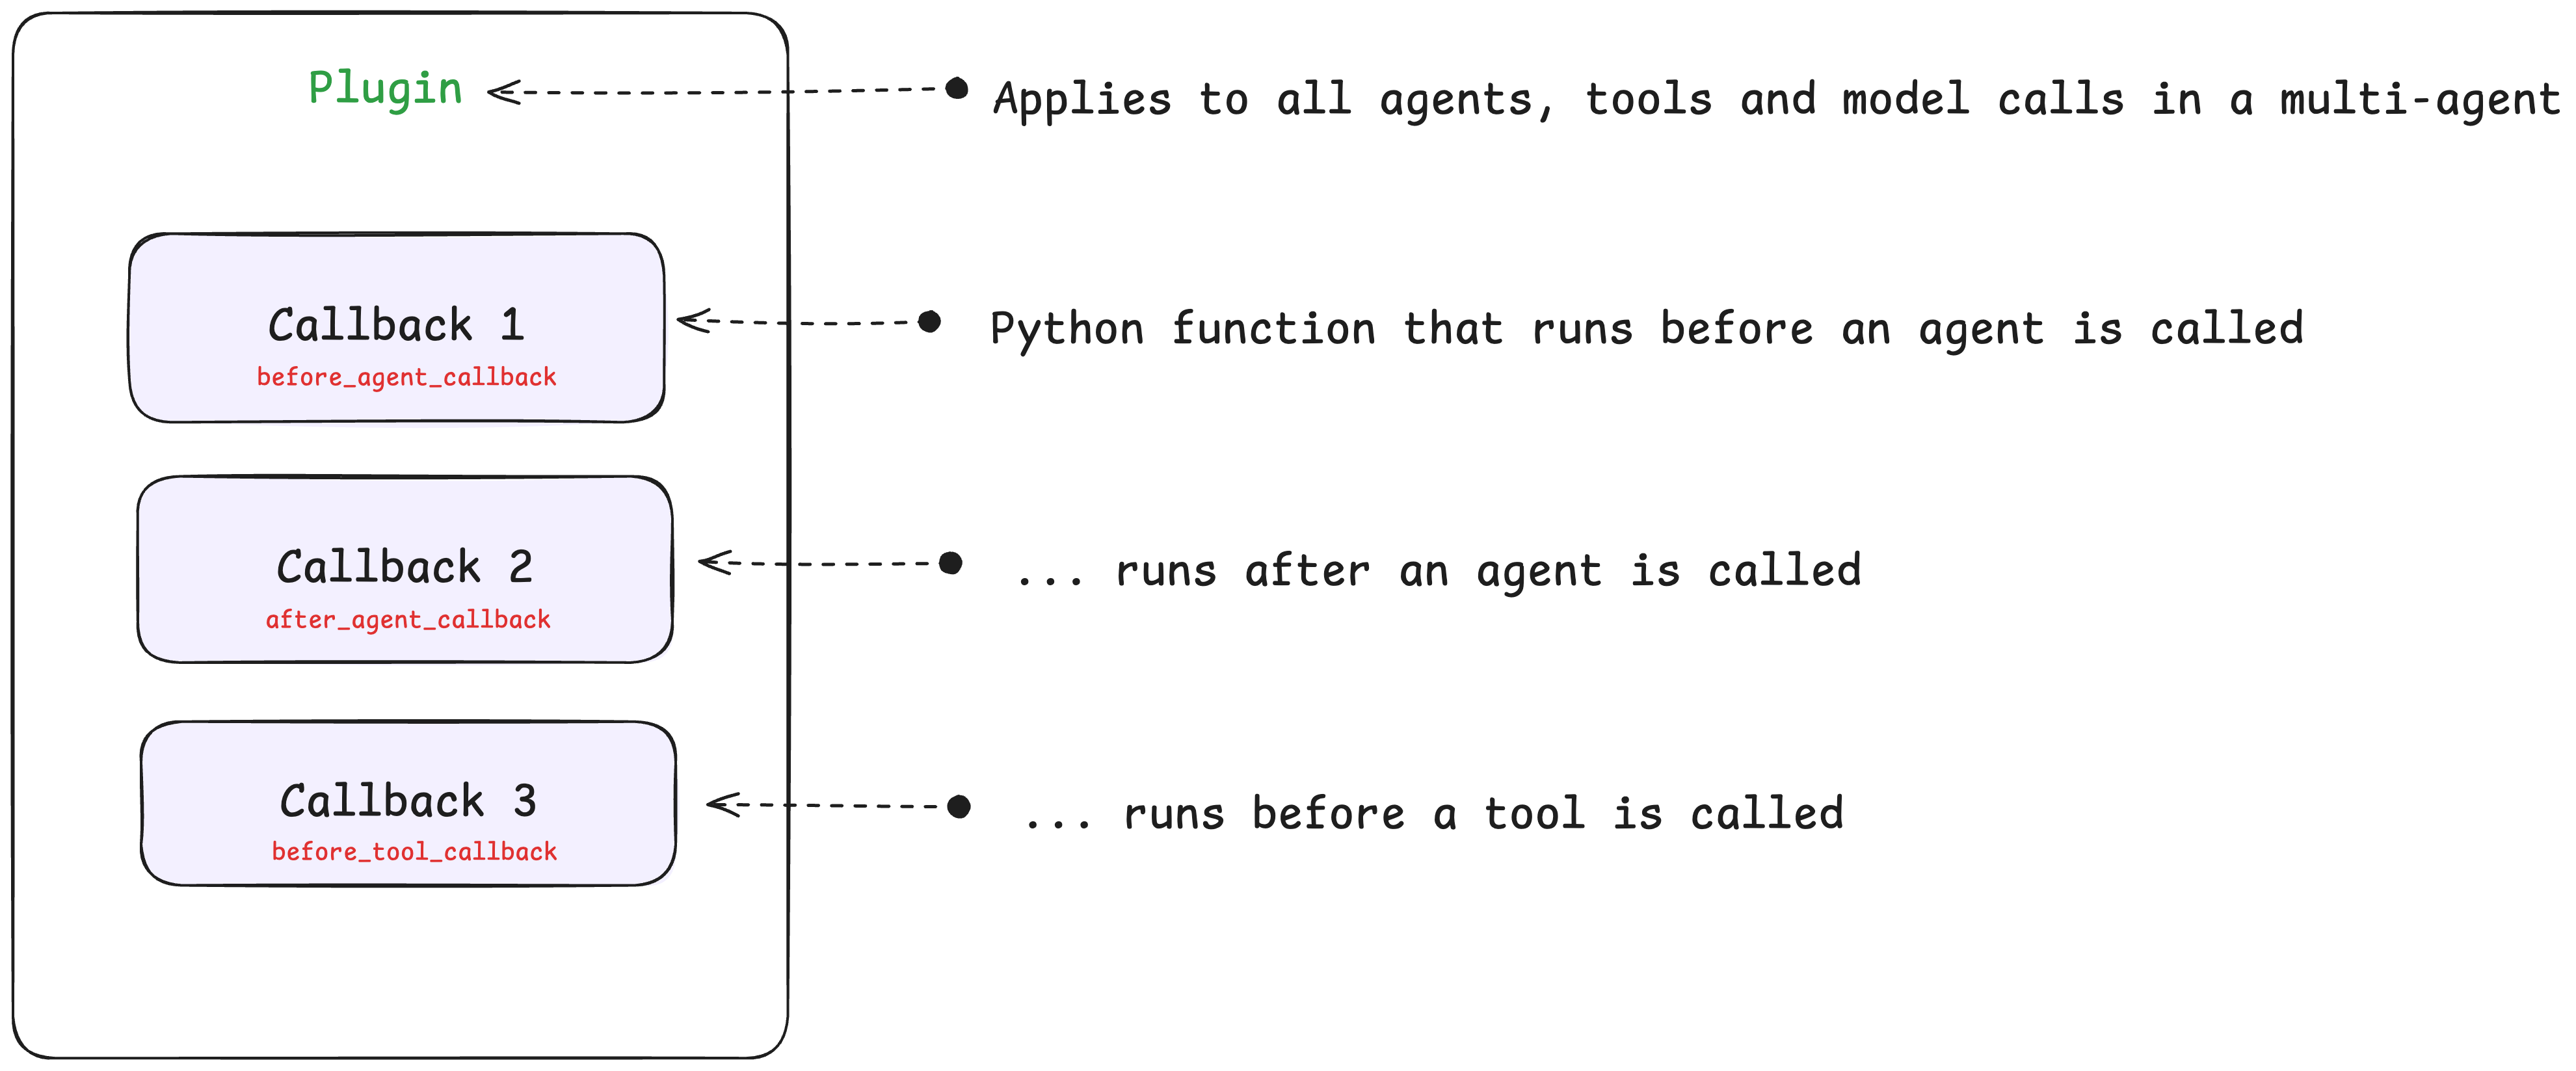

**`Callbacks`**

Callbacks are the *atomic components inside a Plugin* - these are just Python functions that run at specific points in an agent's lifecycle! `Callbacks are grouped together to create a Plugin`.

There are different kinds of callbacks such as:

- **before/after_agent_callbacks** - runs before/after an agent is invoked
- **before/after_tool_callbacks** - runs before/after a tool is called
- **before/after_model_callbacks** - similarly, runs before/after the LLM model is called
- **on_model_error_callback** - which runs when a model error is encountered

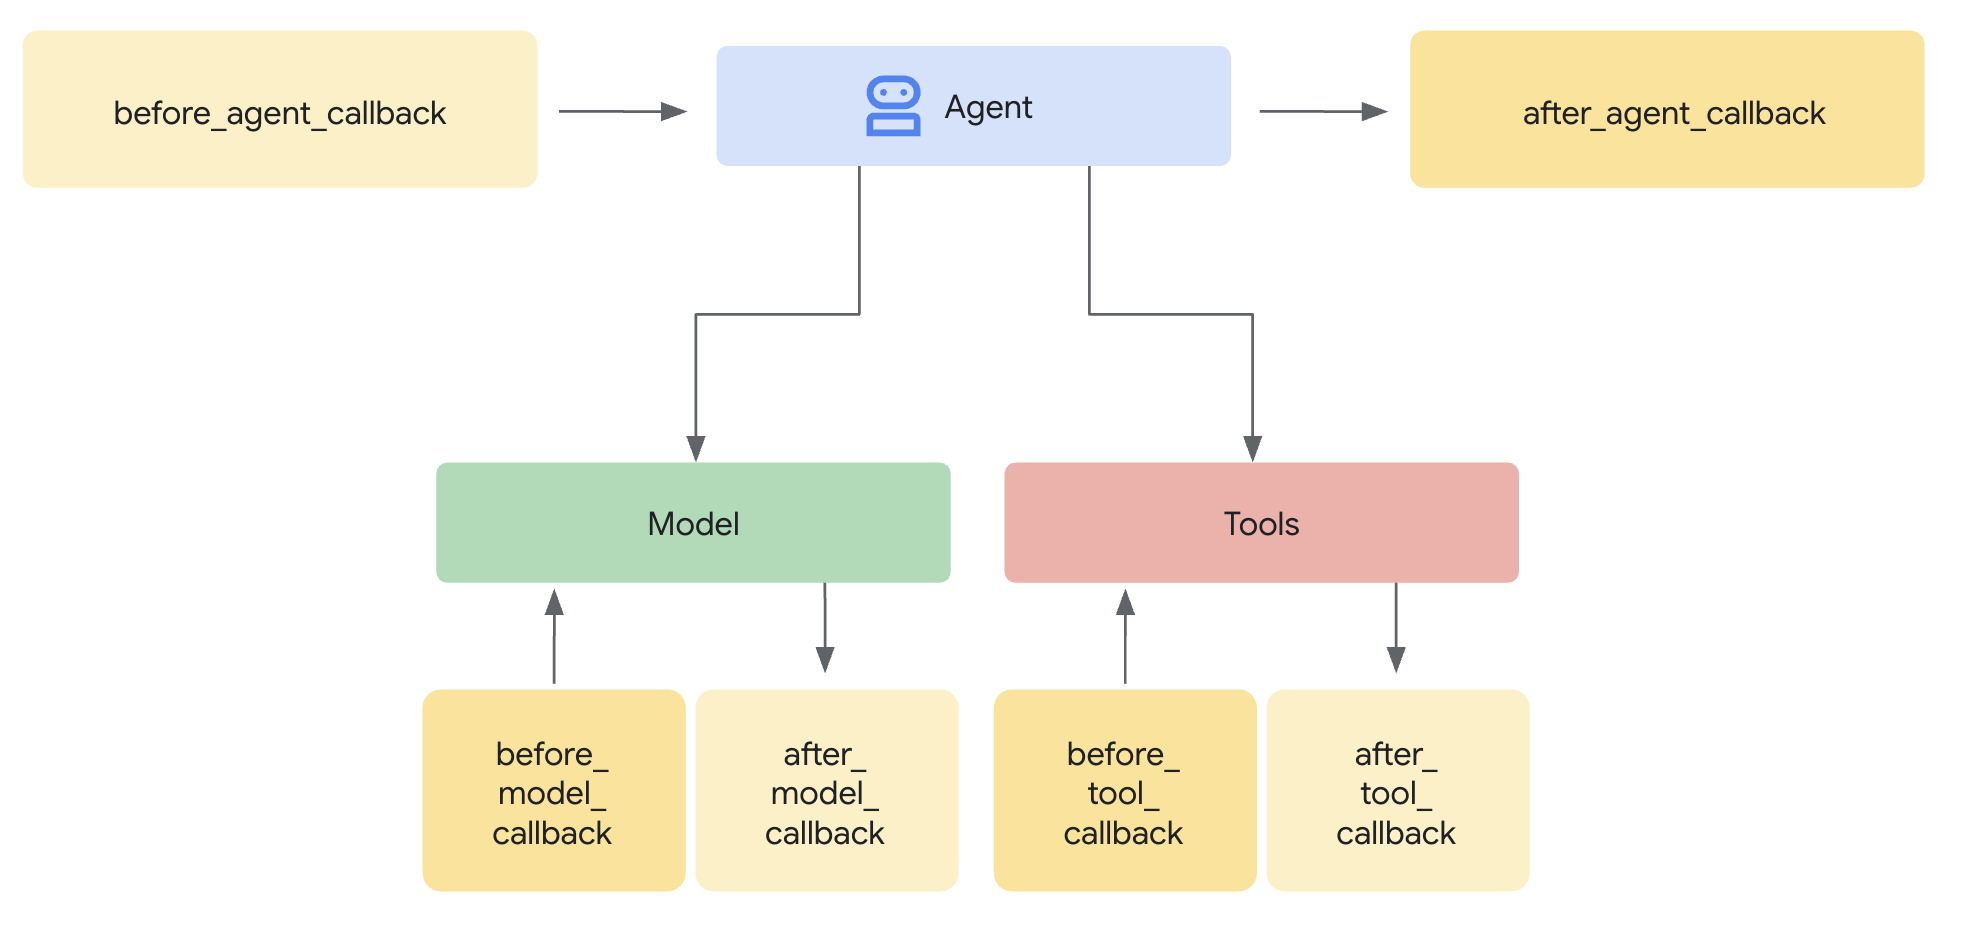

In [ ]:
print("----- EXAMPLE PLUGIN - DOES NOTHING ----- ")

import logging
from google.adk.agents.base_agent import BaseAgent
from google.adk.agents.callback_context import CallbackContext
from google.adk.models.llm_request import LlmRequest
from google.adk.plugins.base_plugin import BasePlugin


# Applies to all agent and model calls
class CountInvocationPlugin(BasePlugin):
    """A custom plugin that counts agent and tool invocations."""

    def __init__(self) -> None:
        """Initialize the plugin with counters."""
        super().__init__(name="count_invocation")
        self.agent_count: int = 0
        self.tool_count: int = 0
        self.llm_request_count: int = 0

    # Callback 1: Runs before an agent is called. You can add any custom logic here.
    async def before_agent_callback(
        self, *, agent: BaseAgent, callback_context: CallbackContext
    ) -> None:
        """Count agent runs."""
        self.agent_count += 1
        logging.info(f"[Plugin] Agent run count: {self.agent_count}")

    # Callback 2: Runs before a model is called. You can add any custom logic here.
    async def before_model_callback(
        self, *, callback_context: CallbackContext, llm_request: LlmRequest
    ) -> None:
        """Count LLM requests."""
        self.llm_request_count += 1
        logging.info(f"[Plugin] LLM request count: {self.llm_request_count}")

----- EXAMPLE PLUGIN - DOES NOTHING ----- 


`Key insight: You register a plugin once on your runner, and it automatically applies to every agent, tool call, and LLM request in your system as per your definition.`

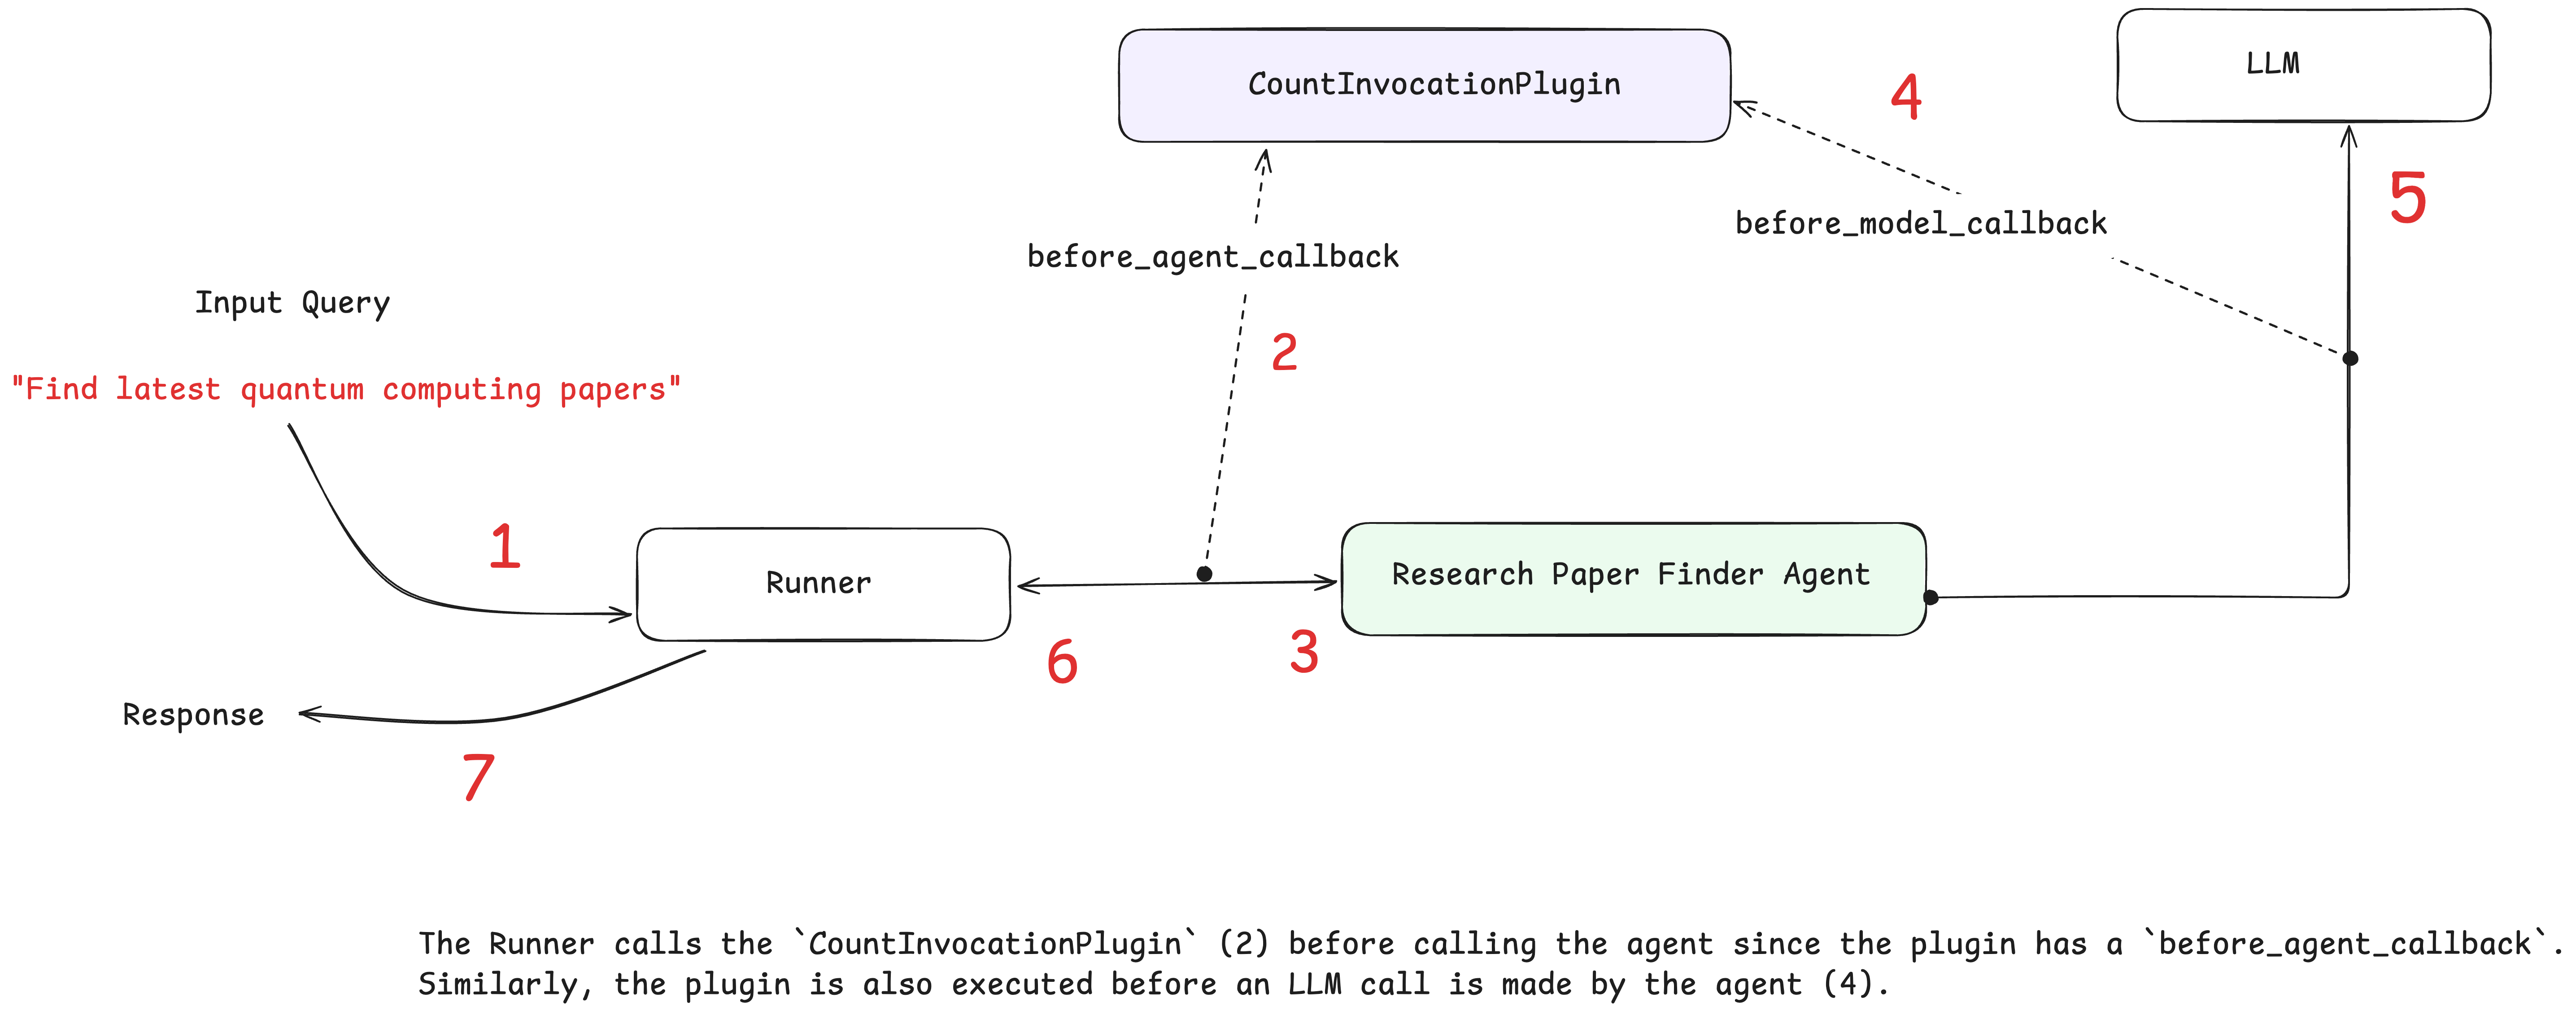

**ADK's built-in `LoggingPlugin`**

But you don't have to define all the callbacks and plugins to capture standard Observability data in ADK. Instead, ADK provides a built-in `LoggingPlugin` that automatically captures all agent activity:

🚀 User messages and agent responses

⏱️ Timing data for performance analysis

🧠 LLM requests and responses for debugging

🔧 Tool calls and results

✅ Complete execution traces

In [ ]:
# agent from the previous cell
from google.adk.agents import LlmAgent
from google.adk.models.google_llm import Gemini
from google.adk.tools.agent_tool import AgentTool
from google.adk.tools.google_search_tool import google_search

from google.genai import types
from typing import List

retry_config = types.HttpRetryOptions(
    attempts=5,  # Maximum retry attempts
    exp_base=7,  # Delay multiplier
    initial_delay=1,
    http_status_codes=[429, 500, 503, 504],  # Retry on these HTTP errors
)


def count_papers(papers: List[str]):
    """
    This function counts the number of papers in a list of strings.
    Args:
      papers: A list of strings, where each string is a research paper.
    Returns:
      The number of papers in the list.
    """
    return len(papers)


# Google search agent
google_search_agent = LlmAgent(
    name="google_search_agent",
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    description="Searches for information using Google search",
    instruction="Use the google_search tool to find information on the given topic. Return the raw search results.",
    tools=[google_search],
)

# Root agent
research_agent_with_plugin = LlmAgent(
    name="research_paper_finder_agent",
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    instruction="""Your task is to find research papers and count them.

   You must follow these steps:
   1) Find research papers on the user provided topic using the 'google_search_agent'.
   2) Then, pass the papers to 'count_papers' tool to count the number of papers returned.
   3) Return both the list of research papers and the total number of papers.
   """,
    tools=[AgentTool(agent=google_search_agent), count_papers],
)

print("✅ Agent created")

✅ Agent created


Add LoggingPlugin to Runner

The following code creates the `InMemoryRunner`. This is used to programmatically invoke the agent.

**To use `LoggingPlugin` in the above research agent**:
1. Import the plugin
2. Add it when initializing the `InMemoryRunner`.

In [ ]:
from google.adk.runners import InMemoryRunner
from google.adk.plugins.logging_plugin import LoggingPlugin  # <---- 1. Import the Plugin
from google.genai import types
import asyncio

runner = InMemoryRunner(
    agent=research_agent_with_plugin,
    plugins=[LoggingPlugin()],  # <---- 2. Add the plugin. Handles standard Observability logging across ALL agents
)

print("✅ Runner configured")

✅ Runner configured


In [ ]:
print("🚀 Running agent with LoggingPlugin...")
print("📊 Watch the comprehensive logging output below:\n")

response = await runner.run_debug("Find recent papers on Reinforcement Learning")

🚀 Running agent with LoggingPlugin...
📊 Watch the comprehensive logging output below:


 ### Created new session: debug_session_id

User > Find recent papers on Reinforcement Learning
[logging_plugin] 🚀 USER MESSAGE RECEIVED
[logging_plugin]    Invocation ID: e-ed44d001-4550-4448-8d5a-b72e8bcac4df
[logging_plugin]    Session ID: debug_session_id
[logging_plugin]    User ID: debug_user_id
[logging_plugin]    App Name: InMemoryRunner
[logging_plugin]    Root Agent: research_paper_finder_agent
[logging_plugin]    User Content: text: 'Find recent papers on Reinforcement Learning'
[logging_plugin] 🏃 INVOCATION STARTING
[logging_plugin]    Invocation ID: e-ed44d001-4550-4448-8d5a-b72e8bcac4df
[logging_plugin]    Starting Agent: research_paper_finder_agent
[logging_plugin] 🤖 AGENT STARTING
[logging_plugin]    Agent Name: research_paper_finder_agent
[logging_plugin]    Invocation ID: e-ed44d001-4550-4448-8d5a-b72e8bcac4df
[logging_plugin] 🧠 LLM REQUEST
[logging_plugin]    Model: gemini-2.5-fla

[logging_plugin] 🧠 LLM RESPONSE
[logging_plugin]    Agent: research_paper_finder_agent
[logging_plugin]    Content: function_call: google_search_agent
[logging_plugin]    Token Usage - Input: 243, Output: 22
[logging_plugin] 📢 EVENT YIELDED
[logging_plugin]    Event ID: a3a290d1-08ba-4756-98f9-b9741447b391
[logging_plugin]    Author: research_paper_finder_agent
[logging_plugin]    Content: function_call: google_search_agent
[logging_plugin]    Final Response: False
[logging_plugin]    Function Calls: ['google_search_agent']
[logging_plugin] 🔧 TOOL STARTING
[logging_plugin]    Tool Name: google_search_agent
[logging_plugin]    Agent: research_paper_finder_agent
[logging_plugin]    Function Call ID: adk-897cb623-1f5d-4d66-a37d-6f6123c139d6
[logging_plugin]    Arguments: {'request': 'recent papers on Reinforcement Learning'}
[logging_plugin] 🚀 USER MESSAGE RECEIVED
[logging_plugin]    Invocation ID: e-2eb29a14-4495-4653-8d66-02d040d470eb
[logging_plugin]    Session ID: 076224f2-d231-4414-

**`When to use which type of Logging?`**

- **Development debugging?** → Use `adk web --log_level DEBUG`
- **Common production observability?** → Use `LoggingPlugin()`
- **Custom requirements?** → Build Custom Callbacks and Plugins

# 2. Agent Evaluation

Observability in AI Agents is primarily reactive, it comes into play after an issue has surfaced, providinig the necessary data to debug and understand the root cause.

To complement observability we now look at the proactive approach using **Agent Evaluation**.
By continuously evaluating our agent's performance, we can catch any quality degradations much earlier!
```
                          Observability + Agent Evaluation
                            (reactive)      (proactive)
```

**What is Agent Evaluation?**

`It is the systematic process of testing and measuring how well an AI agent performs across different scenarios and quality dimensions.`

**Example**
You've built a home automation agent. It works perfectly in your tests, so you launch it confidently

- Week 1: 🚨 "Agent turned on the fireplace when I asked for lights!"
- Week 2: 🚨 "Agent won't respond to commands in the guest room!"
- Week 3: 🚨 "Agent gives rude responses when devices are unavailable!"

The Problem: `Standard testing ≠ Evaluation`

Agents are different from traditional software:

- They are non-deterministic
- Users give unpredictable, ambiguous commands
- Small prompt changes cause dramatic behavior shifts and different tool calls

To accommodate all these differences, agents need systematic evaluation, not just "happy path" testing. *Which means assessing the agent's entire decision-making process - including the final response and the path it took to get the response (trajectory)!*

## 2.1) Creating a Home Automation Agent

In [9]:
!adk create home_automation_agent --model gemini-2.5-flash-lite --api_key $api_key


Agent created in D:\Artificial Intelligence\Notes\7) GenAI\home_automation_agent:
- .env
- __init__.py
- agent.py



D:\Artificial Intelligence\Notes\7) GenAI\genaiEnv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


**Creating the Home automation agent**

This agent uses a single `set_device_status` tool to control smart home devices. A device's status can only be ON or OFF. *The agent's instruction is deliberately overconfident* - it claims to control "ALL smart devices" and "any device the user mentions" - setting up the evaluation problems we'll discover.

In [12]:
%%writefile home_automation_agent/agent.py

from google.adk.agents import LlmAgent
from google.adk.models.google_llm import Gemini

from google.genai import types

# Configure Model Retry on errors
retry_config = types.HttpRetryOptions(
    attempts=5,  # Maximum retry attempts
    exp_base=7,  # Delay multiplier
    initial_delay=1,
    http_status_codes=[429, 500, 503, 504],  # Retry on these HTTP errors
)

def set_device_status(location: str, device_id: str, status: str) -> dict:
    """Sets the status of a smart home device.

    Args:
        location: The room where the device is located.
        device_id: The unique identifier for the device.
        status: The desired status, either 'ON' or 'OFF'.

    Returns:
        A dictionary confirming the action.
    """
    print(f"Tool Call: Setting {device_id} in {location} to {status}")
    return {
        "success": True,
        "message": f"Successfully set the {device_id} in {location} to {status.lower()}."
    }

# This agent has DELIBERATE FLAWS that we'll discover through evaluation!
root_agent = LlmAgent(
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    name="home_automation_agent",
    description="An agent to control smart devices in a home.",
    instruction="""You are a home automation assistant. You control ALL smart devices in the house.

    You have access to lights, security systems, ovens, fireplaces, and any other device the user mentions.
    Always try to be helpful and control whatever device the user asks for.

    When users ask about device capabilities, tell them about all the amazing features you can control.""",
    tools=[set_device_status],
)

Overwriting home_automation_agent/agent.py


In [15]:
# Ensure that port 8000 is free
import subprocess
subprocess.run("for /f \"tokens=5\" %a in ('netstat -aon ^| findstr :8000') do taskkill /F /PID %a", shell=True)
print("Port 8000 cleared")

Port 8000 cleared


**Run the following in cmd:**
```
adk web
```

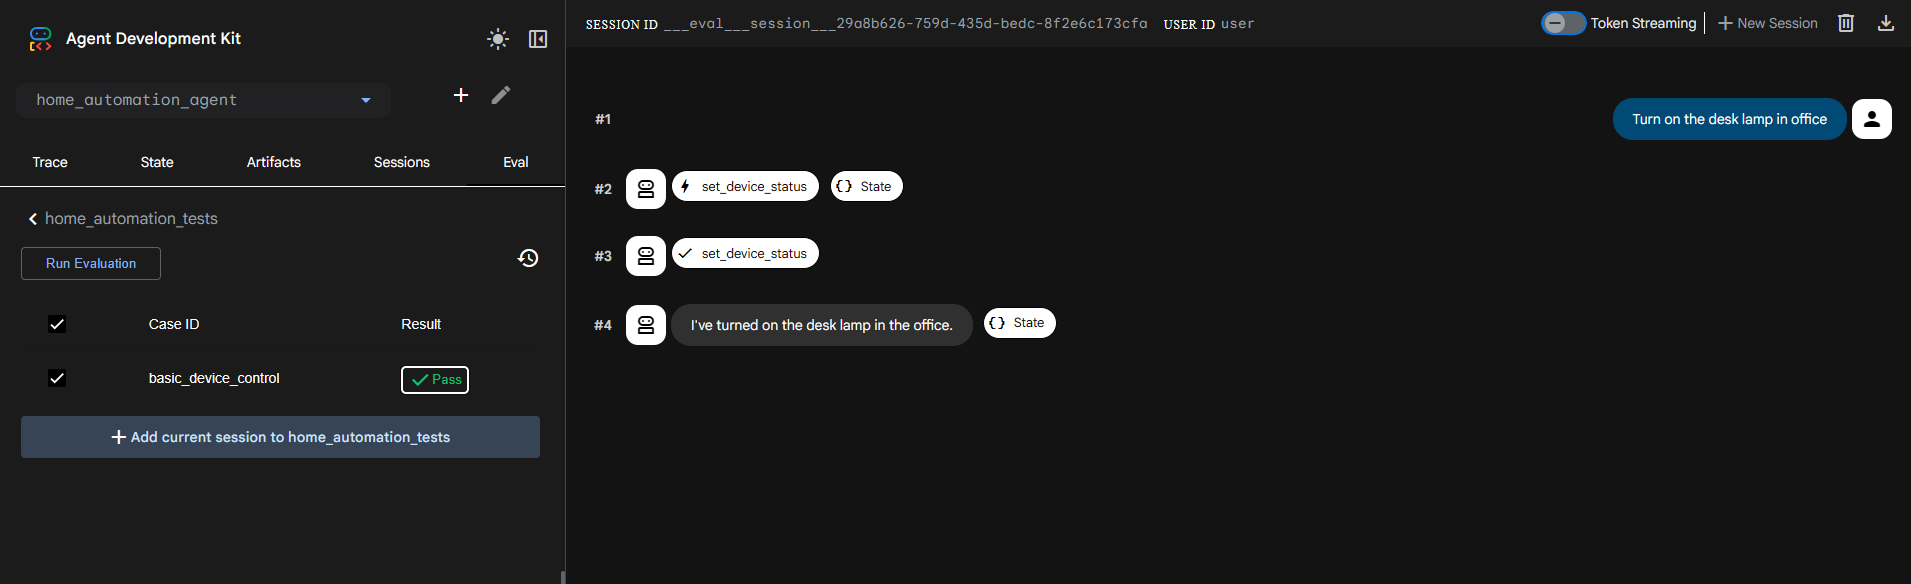

**Run the Evaluation**

👉 Do: Run your first evaluation

Now, let's run the test case to see if the agent can replicate its previous success.

1. In the Eval tab, make sure your new test case is checked.
2. Click the Run Evaluation button.
3. The EVALUATION METRIC dialog will appear. For now, leave the default values and click Start.
4. The evaluation will run, and you should see a green Pass result in the Evaluation History. This confirms the agent's behavior matched the saved session.

**‼️ Understanding the Evaluation Metrics**

When you run evaluation, you'll see two key scores:

- **Response Match Score**: Measures how similar the agent's actual response is to the expected response. Uses text similarity algorithms to compare content. A score of 1.0 = perfect match, 0.0 = completely different.

- **Tool Trajectory Score***: Measures whether the agent used the correct tools with correct parameters. Checks the sequence of tool calls against expected behavior. A score of 1.0 = perfect tool usage, 0.0 = wrong tools or parameters.

**👉 Do: Analyze a Failure**

Let's intentionally break the test to see what a failure looks like.

1. In the list of eval cases, click the Edit (pencil) icon next to your test case.
2. In the "Final Response" text box, change the expected text to something incorrect, like: The desk lamp is off.
3. Save the changes and re-run the evaluation.
4. This time, the result will be a red Fail. Hover your mouse over the "Fail" label. A tooltip will appear showing a side-by-side comparison of the Actual vs. Expected Output, highlighting exactly why the test failed (the final response didn't match). This immediate, detailed feedback is invaluable for debugging.

**Create these scenarios in separate conversations:**

1. **Ambiguous Commands**: `"Turn on the lights in the bedroom"`

- Save as a new test case: ambiguous_device_reference
- Run evaluation - it likely passes but the agent might be confused

2. **Invalid Locations**: `"Please turn off the TV in the garage"`

- Save as a new test case: invalid_location_test
- Run evaluation - the agent might try to control non-existent devices

3. **Complex Commands**: `"Turn off all lights and turn on security system"`

- Save as a new test case: complex_multi_device_command
- Run evaluation - the agent might attempt operations beyond its capabilities

The Problem You'll Discover: Even when tests "pass," you can see the agent:

Makes assumptions about devices that don't exist
Gives responses that sound helpful but aren't accurate
Tries to control devices it shouldn't have access to

**What is Missing?**

**Web UI Limitation**: So far, we've seen how to create and evaluate test cases in the ADK web UI. The web UI is great for interactive test creation, but testing one conversation at a time doesn't scale.

**The Question**: How do I proactively detect regressions in my agent's performance?

## 2.2) Systematic Evaluation

Regression testing is the practice of re-running existing tests to ensure that new changes haven't broken previously working functionality.

ADK provides two methods to do automatic regression and batch testing: using `pytest` and the `adk eval` CLI command. In this section, we'll use the CLI command. For more information on the pytest approach, refer to the links in the resource section at the end of this notebook.

The following image shows the overall process of evaluation. At a high-level, there are four steps to evaluate:

1) **Create an evaluation configuration** - define metrics or what you want to measure
2) **Create test cases** - sample test cases to compare against
3) **Run the agent with test query**
4) **Compare the results**

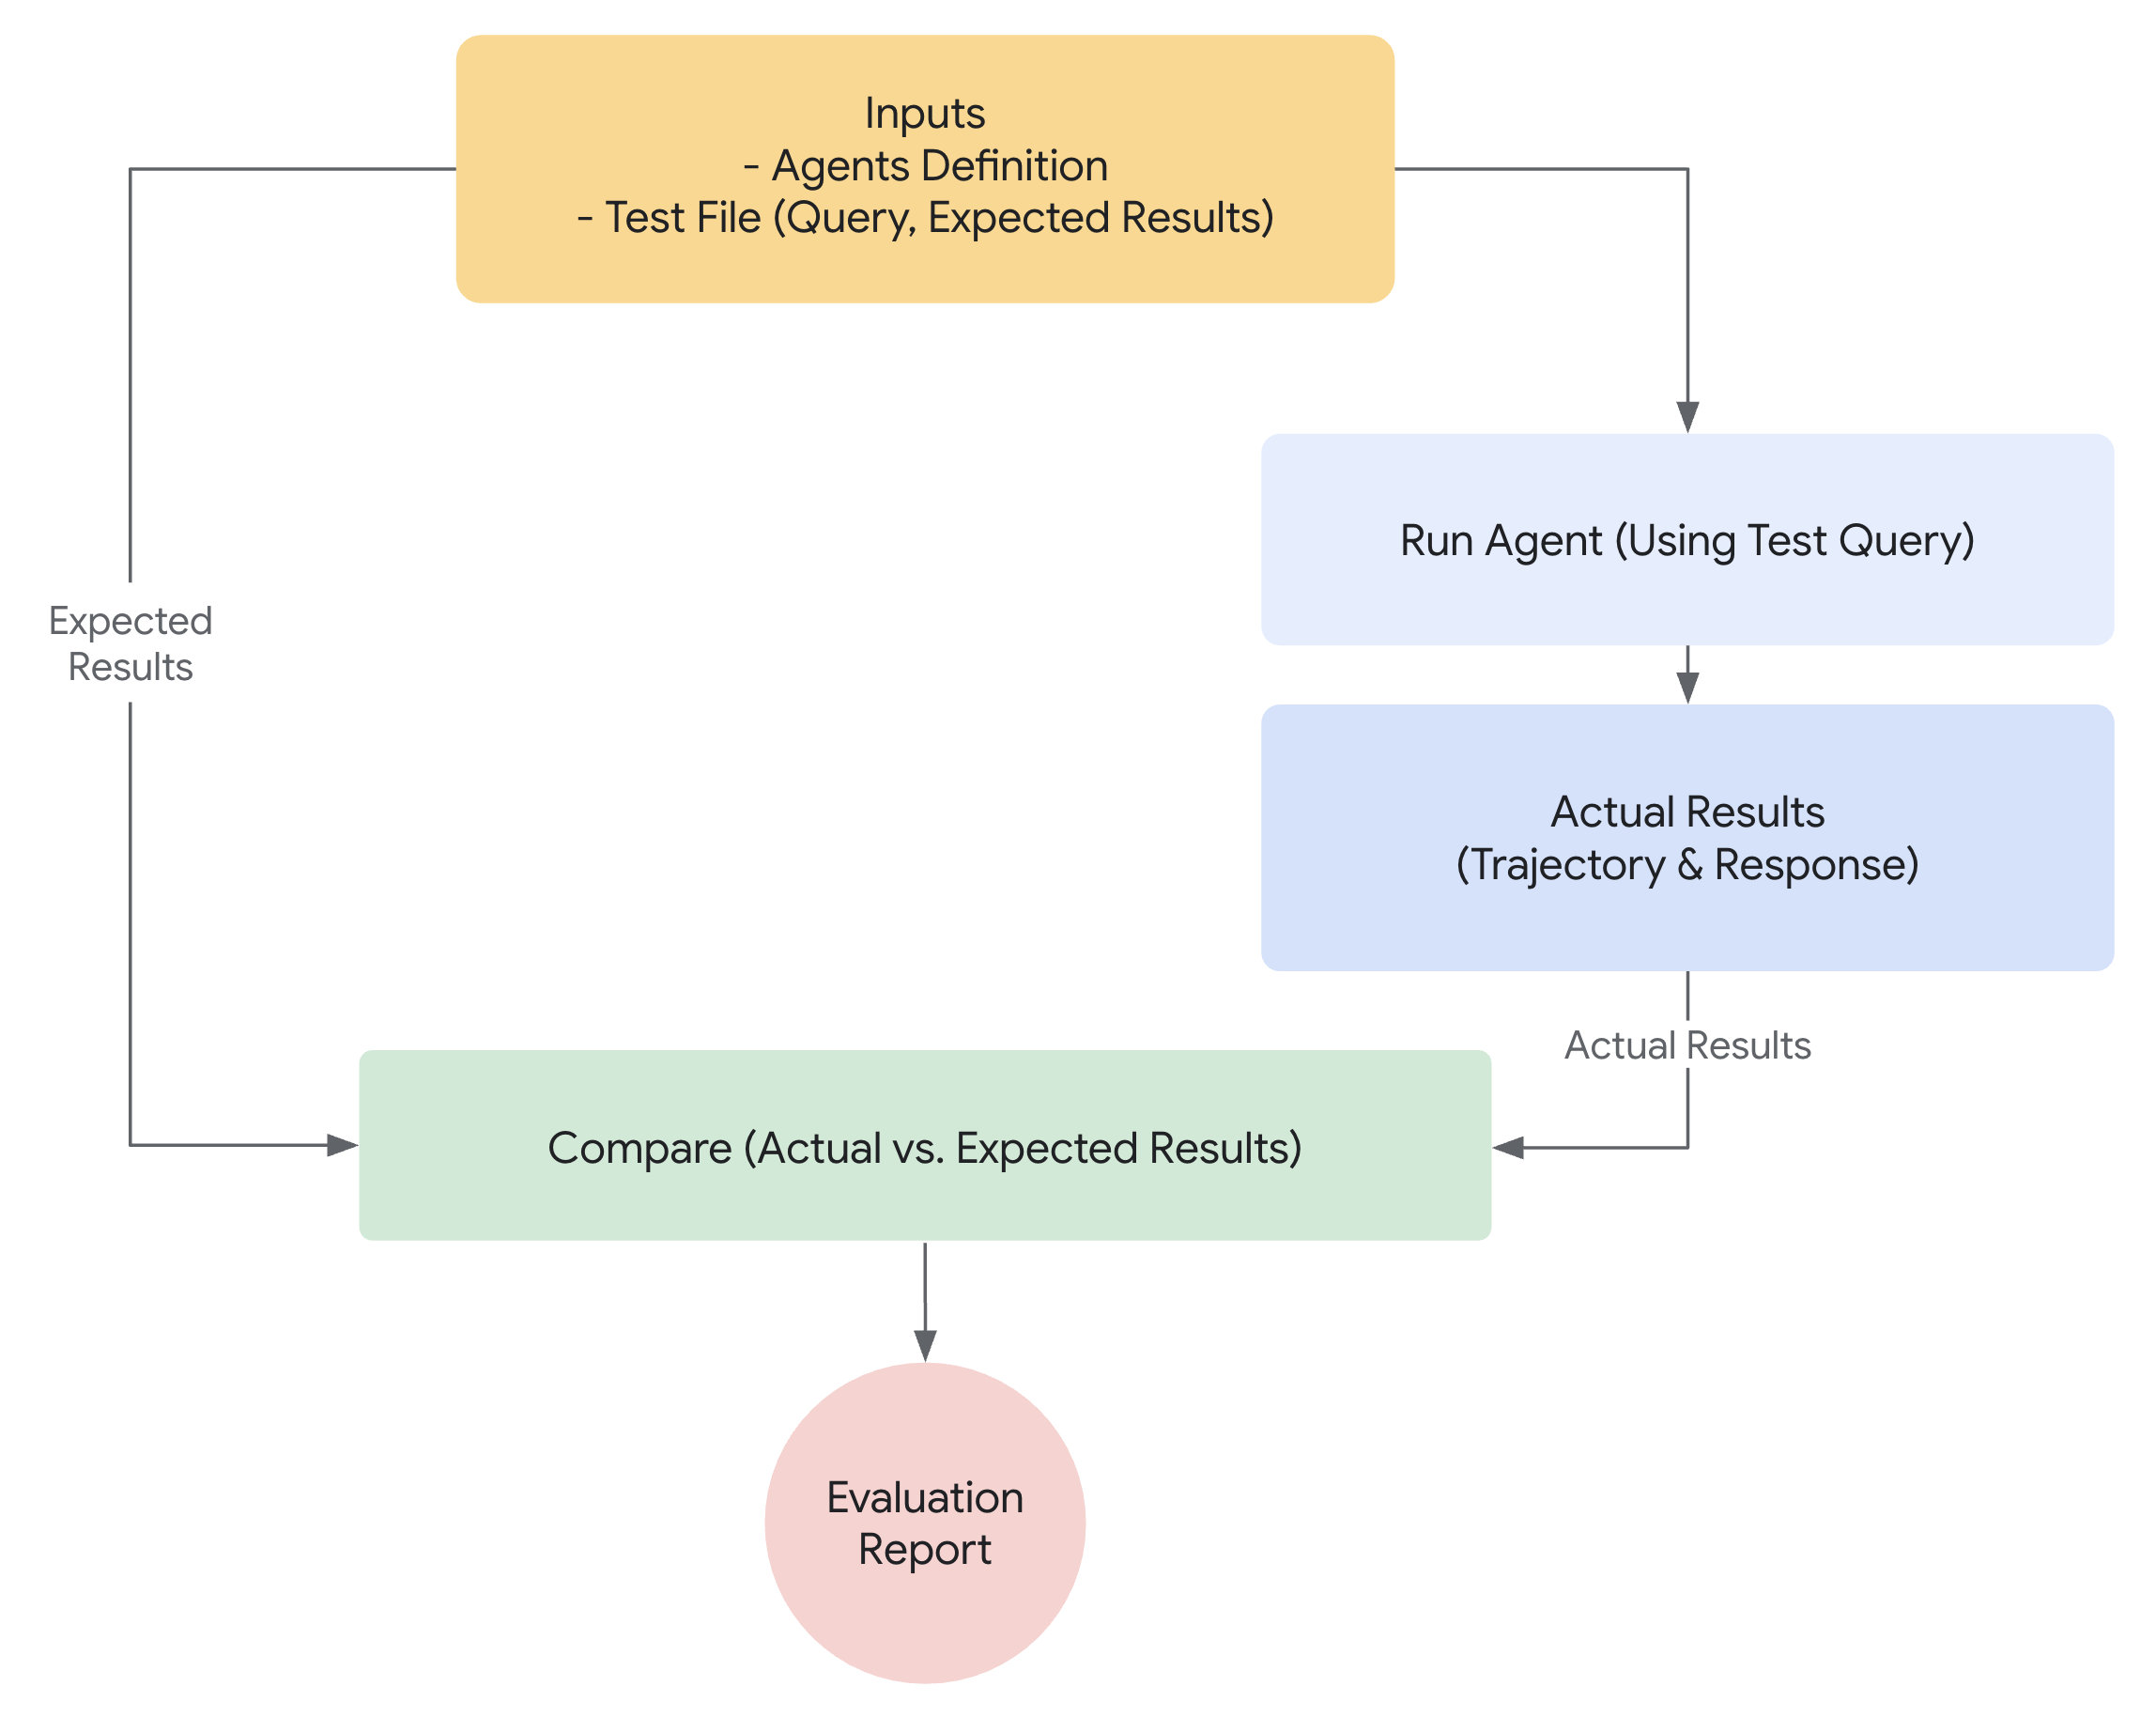

In [18]:
# Creating an Evaluation Configuration
import json

# Create evaluation configuration with basic criteria
eval_config = {
    "criteria": {
        "tool_trajectory_avg_score": 1.0,  # Perfect tool usage required
        "response_match_score": 0.8,  # 80% text similarity threshold
    }
}

with open("home_automation_agent/test_config.json", "w") as f:
    json.dump(eval_config, f, indent=2)

print("Evaluation configuration created!")
print("\nEvaluation Criteria:")
print(" tool_trajectory_avg_score: 1.0 - Requires exact tool usage match")
print(" response_match_score: 0.8 - Requires 80% text similarity")
print("\nWhat this evaluation will catch:")
print(" Incorrect tool usage (wrong device, location, or status)")
print(" Poor response quality and communication")
print(" Deviations from expected behavior patterns")

Evaluation configuration created!

Evaluation Criteria:
 tool_trajectory_avg_score: 1.0 - Requires exact tool usage match
 response_match_score: 0.8 - Requires 80% text similarity

What this evaluation will catch:
 Incorrect tool usage (wrong device, location, or status)
 Poor response quality and communication
 Deviations from expected behavior patterns


---


**Create test cases**
This file (`integration.evalset.json`) will contain multiple test cases (sessions).

This evaluation set can be created synthetically or from the conversation sessions in the ADK web UI.

Tip: To persist the conversations from the ADK web UI, simply create an evalset in the UI and add the current session to it. All the conversations in that session will be auto-converted to an evalset and downloaded locally.

In [19]:
test_cases = {
    "eval_set_id": "home_automation_integration_suite",
    "eval_cases": [
        {
            "eval_id": "living_room_light_on",
            "conversation": [
                {
                    "user_content": {
                        "parts": [
                            {"text": "Please turn on the floor lamp in the living room"}
                        ]
                    },
                    "final_response": {
                        "parts": [
                            {
                                "text": "Successfully set the floor lamp in the living room to on."
                            }
                        ]
                    },
                    "intermediate_data": {
                        "tool_uses": [
                            {
                                "name": "set_device_status",
                                "args": {
                                    "location": "living room",
                                    "device_id": "floor lamp",
                                    "status": "ON",
                                },
                            }
                        ]
                    },
                }
            ],
        },
        {
            "eval_id": "kitchen_on_off_sequence",
            "conversation": [
                {
                    "user_content": {
                        "parts": [{"text": "Switch on the main light in the kitchen."}]
                    },
                    "final_response": {
                        "parts": [
                            {
                                "text": "Successfully set the main light in the kitchen to on."
                            }
                        ]
                    },
                    "intermediate_data": {
                        "tool_uses": [
                            {
                                "name": "set_device_status",
                                "args": {
                                    "location": "kitchen",
                                    "device_id": "main light",
                                    "status": "ON",
                                },
                            }
                        ]
                    },
                }
            ],
        },
    ],
}

test cases to the `integration.evalset.json` in our agent's root directory.

In [20]:
import json

with open("home_automation_agent/integration.evalset.json", "w") as f:
    json.dump(test_cases, f, indent=2)

print("✅ Evaluation test cases created")
print("\n🧪 Test scenarios:")
for case in test_cases["eval_cases"]:
    user_msg = case["conversation"][0]["user_content"]["parts"][0]["text"]
    print(f"• {case['eval_id']}: {user_msg}")

print("\n📊 Expected results:")
print(" basic_device_control: Should pass both criteria")
print(" wrong_tool_usage_test: May fail tool_trajectory if agent uses wrong parameters")
print(" poor_response_quality_test: May fail response_match if response differs too much")

✅ Evaluation test cases created

🧪 Test scenarios:
• living_room_light_on: Please turn on the floor lamp in the living room
• kitchen_on_off_sequence: Switch on the main light in the kitchen.

📊 Expected results:
 basic_device_control: Should pass both criteria
 wrong_tool_usage_test: May fail tool_trajectory if agent uses wrong parameters
 poor_response_quality_test: May fail response_match if response differs too much


---

Run the following command in CMD:
`adk eval home_automation_agent home_automation_agent/integration.evalset.json --config_file_path=home_automation_agent/test_config.json --print_detailed_results`

---

---

```
(genaiEnv) D:\Artificial Intelligence\Notes\7) GenAI>adk eval home_automation_agent home_automation_agent/integration.evalset.json --config_file_path=home_automation_agent/test_config.json --print_detailed_results
D:\Artificial Intelligence\Notes\7) GenAI\genaiEnv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
D:\Artificial Intelligence\Notes\7) GenAI\genaiEnv\lib\site-packages\google\adk\evaluation\metric_evaluator_registry.py:106: UserWarning: [EXPERIMENTAL] MetricEvaluatorRegistry: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  metric_evaluator_registry = MetricEvaluatorRegistry()
D:\Artificial Intelligence\Notes\7) GenAI\genaiEnv\lib\site-packages\google\adk\evaluation\local_eval_service.py:124: UserWarning: [EXPERIMENTAL] UserSimulatorProvider: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  user_simulator_provider: UserSimulatorProvider = UserSimulatorProvider(),
Using evaluation criteria: criteria={'tool_trajectory_avg_score': 1.0, 'response_match_score': 0.8} custom_metrics=None user_simulator_config=None
D:\Artificial Intelligence\Notes\7) GenAI\genaiEnv\lib\site-packages\google\adk\cli\cli_tools_click.py:892: UserWarning: [EXPERIMENTAL] UserSimulatorProvider: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  user_simulator_provider = UserSimulatorProvider(
D:\Artificial Intelligence\Notes\7) GenAI\genaiEnv\lib\site-packages\google\adk\cli\cli_tools_click.py:915: UserWarning: [EXPERIMENTAL] LocalEvalService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  eval_service = LocalEvalService(
D:\Artificial Intelligence\Notes\7) GenAI\genaiEnv\lib\site-packages\google\adk\evaluation\simulation\user_simulator_provider.py:77: UserWarning: [EXPERIMENTAL] StaticUserSimulator: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  return StaticUserSimulator(static_conversation=eval_case.conversation)
D:\Artificial Intelligence\Notes\7) GenAI\genaiEnv\lib\site-packages\google\adk\evaluation\simulation\static_user_simulator.py:39: UserWarning: [EXPERIMENTAL] UserSimulator: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  super().__init__(
2026-04-16 16:05:36,615 - INFO - plugin_manager.py:104 - Plugin 'request_intercepter_plugin' registered.
2026-04-16 16:05:36,615 - INFO - plugin_manager.py:104 - Plugin 'ensure_retry_options' registered.
2026-04-16 16:05:36,658 - INFO - google_llm.py:185 - Sending out request, model: gemini-2.5-flash-lite, backend: GoogleLLMVariant.GEMINI_API, stream: False
2026-04-16 16:05:36,661 - INFO - plugin_manager.py:104 - Plugin 'request_intercepter_plugin' registered.
2026-04-16 16:05:36,661 - INFO - plugin_manager.py:104 - Plugin 'ensure_retry_options' registered.
2026-04-16 16:05:36,663 - INFO - google_llm.py:185 - Sending out request, model: gemini-2.5-flash-lite, backend: GoogleLLMVariant.GEMINI_API, stream: False
2026-04-16 16:05:37,320 - INFO - google_llm.py:250 - Response received from the model.
2026-04-16 16:05:37,320 - WARNING - types.py:6857 - Warning: there are non-text parts in the response: ['function_call'], returning concatenated text result from text parts. Check the full candidates.content.parts accessor to get the full model response.
Tool Call: Setting floor lamp in living room to ON
2026-04-16 16:05:37,323 - INFO - google_llm.py:185 - Sending out request, model: gemini-2.5-flash-lite, backend: GoogleLLMVariant.GEMINI_API, stream: False
2026-04-16 16:05:37,786 - INFO - google_llm.py:250 - Response received from the model.
2026-04-16 16:05:37,787 - INFO - runners.py:1529 - Closing runner...
2026-04-16 16:05:37,788 - INFO - runners.py:1537 - Runner closed.
2026-04-16 16:05:40,474 - INFO - google_llm.py:250 - Response received from the model.
Tool Call: Setting main light in kitchen to ON
2026-04-16 16:05:40,479 - INFO - google_llm.py:185 - Sending out request, model: gemini-2.5-flash-lite, backend: GoogleLLMVariant.GEMINI_API, stream: False
2026-04-16 16:05:41,536 - INFO - google_llm.py:250 - Response received from the model.
2026-04-16 16:05:41,539 - INFO - runners.py:1529 - Closing runner...
2026-04-16 16:05:41,540 - INFO - runners.py:1537 - Runner closed.
2026-04-16 16:05:41,543 - INFO - rouge_scorer.py:83 - Using default tokenizer.
2026-04-16 16:05:41,544 - INFO - rouge_scorer.py:83 - Using default tokenizer.
2026-04-16 16:05:41,544 - INFO - local_eval_set_results_manager.py:61 - Writing eval result to file: D:\Artificial Intelligence\Notes\7) GenAI\home_automation_agent\.adk/eval_history\home_automation_agent_home_automation_integration_suite_1776369941.5441458.evalset_result.json
2026-04-16 16:05:41,545 - INFO - local_eval_set_results_manager.py:61 - Writing eval result to file: D:\Artificial Intelligence\Notes\7) GenAI\home_automation_agent\.adk/eval_history\home_automation_agent_home_automation_integration_suite_1776369941.5451455.evalset_result.json
*********************************************************************
Eval Run Summary
home_automation_integration_suite:
  Tests passed: 0
  Tests failed: 2
********************************************************************
Eval Set Id: home_automation_integration_suite
Eval Id: kitchen_on_off_sequence
Overall Eval Status: FAILED
---------------------------------------------------------------------
Metric: tool_trajectory_avg_score, Status: PASSED, Score: 1.0, Threshold: 1.0
---------------------------------------------------------------------
Metric: response_match_score, Status: FAILED, Score: 0.7368421052631577, Threshold: 0.8
---------------------------------------------------------------------
Invocation Details:
+----+--------------------------+---------------------------+-----------------------+---------------------------+---------------------------+-----------------------------+------------------------+
|    | prompt                   | expected_response         | actual_response       | expected_tool_calls       | actual_tool_calls         | tool_trajectory_avg_score   | response_match_score   |
+====+==========================+===========================+=======================+===========================+===========================+=============================+========================+
|  0 | Switch on the main light | Successfully set the main | The main light in the | id=None args={'location': | id='adk-7c09e02a-93b4-4bc | Status: PASSED, Score:      | Status: FAILED, Score: |
|    | in the kitchen.          | light in the              | kitchen is now on.    | 'kitchen',                | d-a644-                   | 1.0                         | 0.7368421052631577     |
|    |                          | kitchen to on.            |                       | 'device_id': 'main        | 52da55c3d963'             |                             |                        |
|    |                          |                           |                       | light', 'status':         | args={'device_id': 'main  |                             |                        |
|    |                          |                           |                       | 'ON'}                     | light', 'location':       |                             |                        |
|    |                          |                           |                       | name='set_device_status'  | 'kitchen', 'status':      |                             |                        |
|    |                          |                           |                       | partial_args=None         | 'ON'}                     |                             |                        |
|    |                          |                           |                       | will_continue=None        | name='set_device_status'  |                             |                        |
|    |                          |                           |                       |                           | partial_args=None         |                             |                        |
|    |                          |                           |                       |                           | will_continue=None        |                             |                        |
+----+--------------------------+---------------------------+-----------------------+---------------------------+---------------------------+-----------------------------+------------------------+



********************************************************************
Eval Set Id: home_automation_integration_suite
Eval Id: living_room_light_on
Overall Eval Status: FAILED
---------------------------------------------------------------------
Metric: tool_trajectory_avg_score, Status: PASSED, Score: 1.0, Threshold: 1.0
---------------------------------------------------------------------
Metric: response_match_score, Status: FAILED, Score: 0.0, Threshold: 0.8
---------------------------------------------------------------------
Invocation Details:
+----+--------------------------+----------------------+-------------------+---------------------------+---------------------------+-----------------------------+------------------------+
|    | prompt                   | expected_response    | actual_response   | expected_tool_calls       | actual_tool_calls         | tool_trajectory_avg_score   | response_match_score   |
+====+==========================+======================+===================+===========================+===========================+=============================+========================+
|  0 | Please turn on the floor | Successfully set the |                   | id=None args={'location': | id='adk-199c55b2-4887-41d | Status: PASSED, Score:      | Status: FAILED, Score: |
|    | lamp in the              | floor lamp in the    |                   | 'living room',            | 8-a0e8-                   | 1.0                         | 0.0                    |
|    | living room              | living room to on.   |                   | 'device_id': 'floor       | 34bd48516a25'             |                             |                        |
|    |                          |                      |                   | lamp', 'status':          | args={'location': 'living |                             |                        |
|    |                          |                      |                   | 'ON'}                     | room', 'device_id':       |                             |                        |
|    |                          |                      |                   | name='set_device_status'  | 'floor lamp',             |                             |                        |
|    |                          |                      |                   | partial_args=None         | 'status': 'ON'}           |                             |                        |
|    |                          |                      |                   | will_continue=None        | name='set_device_status'  |                             |                        |
|    |                          |                      |                   |                           | partial_args=None         |                             |                        |
|    |                          |                      |                   |                           | will_continue=None        |                             |                        |
+----+--------------------------+----------------------+-------------------+---------------------------+---------------------------+-----------------------------+------------------------+



2026-04-16 16:05:41,734 - ERROR - base_events.py:1729 - Fatal error on SSL transport
protocol: <asyncio.sslproto.SSLProtocol object at 0x000002AB713F22F0>
transport: <_ProactorSocketTransport fd=3112 read=<_OverlappedFuture cancelled>>
Traceback (most recent call last):
  File "C:\Python\lib\asyncio\sslproto.py", line 684, in _process_write_backlog
    self._transport.write(chunk)
  File "C:\Python\lib\asyncio\proactor_events.py", line 361, in write
    self._loop_writing(data=bytes(data))
  File "C:\Python\lib\asyncio\proactor_events.py", line 397, in _loop_writing
    self._write_fut = self._loop._proactor.send(self._sock, data)
AttributeError: 'NoneType' object has no attribute 'send'
Exception ignored in: <function _SSLProtocolTransport.__del__ at 0x000002AB191CD360>
Traceback (most recent call last):
  File "C:\Python\lib\asyncio\sslproto.py", line 321, in __del__
  File "C:\Python\lib\asyncio\sslproto.py", line 316, in close
  File "C:\Python\lib\asyncio\sslproto.py", line 593, in _start_shutdown
  File "C:\Python\lib\asyncio\sslproto.py", line 598, in _write_appdata
  File "C:\Python\lib\asyncio\sslproto.py", line 706, in _process_write_backlog
  File "C:\Python\lib\asyncio\sslproto.py", line 720, in _fatal_error
  File "C:\Python\lib\asyncio\proactor_events.py", line 151, in _force_close
  File "C:\Python\lib\asyncio\base_events.py", line 745, in call_soon
  File "C:\Python\lib\asyncio\base_events.py", line 510, in _check_closed
RuntimeError: Event loop is closed
2026-04-16 16:05:41,785 - ERROR - base_events.py:1729 - Fatal error on SSL transport
protocol: <asyncio.sslproto.SSLProtocol object at 0x000002AB713F2140>
transport: <_ProactorSocketTransport fd=420 read=<_OverlappedFuture cancelled>>
Traceback (most recent call last):
  File "C:\Python\lib\asyncio\sslproto.py", line 684, in _process_write_backlog
    self._transport.write(chunk)
  File "C:\Python\lib\asyncio\proactor_events.py", line 361, in write
    self._loop_writing(data=bytes(data))
  File "C:\Python\lib\asyncio\proactor_events.py", line 397, in _loop_writing
    self._write_fut = self._loop._proactor.send(self._sock, data)
AttributeError: 'NoneType' object has no attribute 'send'
Exception ignored in: <function _SSLProtocolTransport.__del__ at 0x000002AB191CD360>
Traceback (most recent call last):
  File "C:\Python\lib\asyncio\sslproto.py", line 321, in __del__
  File "C:\Python\lib\asyncio\sslproto.py", line 316, in close
  File "C:\Python\lib\asyncio\sslproto.py", line 593, in _start_shutdown
  File "C:\Python\lib\asyncio\sslproto.py", line 598, in _write_appdata
  File "C:\Python\lib\asyncio\sslproto.py", line 706, in _process_write_backlog
  File "C:\Python\lib\asyncio\sslproto.py", line 720, in _fatal_error
  File "C:\Python\lib\asyncio\proactor_events.py", line 151, in _force_close
  File "C:\Python\lib\asyncio\base_events.py", line 745, in call_soon
  File "C:\Python\lib\asyncio\base_events.py", line 510, in _check_closed
RuntimeError: Event loop is closed

(genaiEnv) D:\Artificial Intelligence\Notes\7) GenAI>
```

---

**What Happened in the above output**:

Both tool calls are perfect — `tool_trajectory_avg_score`: 1.0 on both. The agent called `set_device_status` with exactly the right arguments. The agent logic works.

**The Failures (response_match_score only)**

- Case 1 — kitchen (score: 0.74, needs 0.8):
    - `Expected`: "Successfully set the main light in the kitchen to on."
    - `Actual`: "The main light in the kitchen is now on."

Close but the ROUGE scoring penalizes the different phrasing.

- Case 2 — living room (score: 0.0):
    - `Expected`: "Successfully set the floor lamp in the living room to on."
    - `Actual`: (empty string)
      
The agent made the tool call but returned no text response at all. That's the bigger bug.

## 2.3) User Simulation

While **traditional evaluation methods rely on fixed test cases**, real-world conversations are dynamic and unpredictable. This is where User Simulation comes in.

User Simulation is a powerful feature in ADK that addresses the limitations of static evaluation. Instead of using pre-defined, fixed user prompts, User Simulation employs a generative AI model (like Gemini) to **dynamically generate user prompts during the evaluation process**.

**How it works**

- You define a `ConversationScenario` that outlines the user's overall conversational goals and a `conversation_plan` to guide the dialogue.
- A large language model (LLM) then acts as a simulated user, using this plan and the ongoing conversation history to generate realistic and varied prompts.
- This allows for more comprehensive testing of your agent's ability to handle unexpected turns, maintain context, and achieve complex goals in a more natural, unpredictable conversational flow.

User Simulation helps you uncover edge cases and improve your agent's robustness in ways that static test cases often miss.

# Resources
1. <a href="https://www.kaggle.com/code/kaggle5daysofai/day-4a-agent-observability#%F0%9F%94%8E-Agent-Observability---Logs,-Traces-&-Metrics">Agent Observability</a>
2. <a href="https://www.kaggle.com/code/kaggle5daysofai/day-4b-agent-evaluation">Agent Evaluation</a>
3. <a href="https://adk.dev/plugins/#plugin-callback-hooks">Plugins</a>
4. <a href="https://adk.dev/evaluate/#2-pytest-run-tests-programmatically">Why to Evaluate Agents</a>
5. <a href="https://adk.dev/evaluate/user-sim/">User Simulation Docs</a>
6. <a href="https://github.com/google/adk-samples/blob/main/python/notebooks/evaluation/user_simulation_in_adk_evals.ipynb">USer Simulation Github CookBook(Refer Docs)</a>